In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

In [ ]:
df = pd.read_csv("/content/PreviousDataset.csv")

In [ ]:
numeric_cols = ['SSTA', 'ClimSST', 'Depth', 'Longitude_Degrees',
                'Latitude_Degrees', 'Average_Bleaching', 'Windspeed',
                'TSA', 'TSA_DHW', 'SSTA_DHW', 'SSTA_Minimum']
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year

# Filter
df = df[df['SSTA'] > 0]
df = df[df['Year'] >= 2003]

In [ ]:
drop_cols = ['City_Town', 'City_Town_2', 'City_Town_3', 'Ocean', 'Realm', 'Ecoregion', 'ID', 'Country_Name', 'State_Island_Province', 'Date2', 'SSTA_Mean']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Month encoding
df['Month'] = df['Date'].dt.month

###  One-Hot Encoding for Month

In [ ]:
month_dummies = pd.get_dummies(df['Month'], prefix='Month', drop_first=False)
df = pd.concat([df, month_dummies], axis=1)
df = df.drop(columns=['Month', 'Date', 'Year'])

In [ ]:
df.columns

Index(['Latitude_Degrees', 'Longitude_Degrees', 'Depth', 'Average_Bleaching',
       'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean',
       'Temperature_Minimum', 'Temperature_Maximum',
       'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation',
       'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW',
       'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA',
       'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean',
       'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax',
       'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation',
       'TSA_DHWMax', 'TSA_DHWMean', 'Month_1', 'Month_2', 'Month_3', 'Month_4',
       'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10',
       'Month_11', 'Month_12'],
      dtype='object')

# PCA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
X = df.drop("Average_Bleaching", axis=1)
Y = df["Average_Bleaching"]

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
X_train_raw_5features, X_test_raw_features = X_train_raw[['SSTA', 'ClimSST', 'Depth', 'Longitude_Degrees', 'Latitude_Degrees']].copy(), X_test_raw[['SSTA', 'ClimSST', 'Depth', 'Longitude_Degrees', 'Latitude_Degrees']].copy()

X_train_raw_month, X_test_raw_month = X_train_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy(), X_test_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy()

X_train_raw = X_train_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])
X_test_raw = X_test_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])

In [ ]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

In [ ]:
pca = PCA(n_components=0.75)
X_train_pca = pca.fit_transform(X_train_ss)
X_test_pca = pca.transform(X_test_ss)

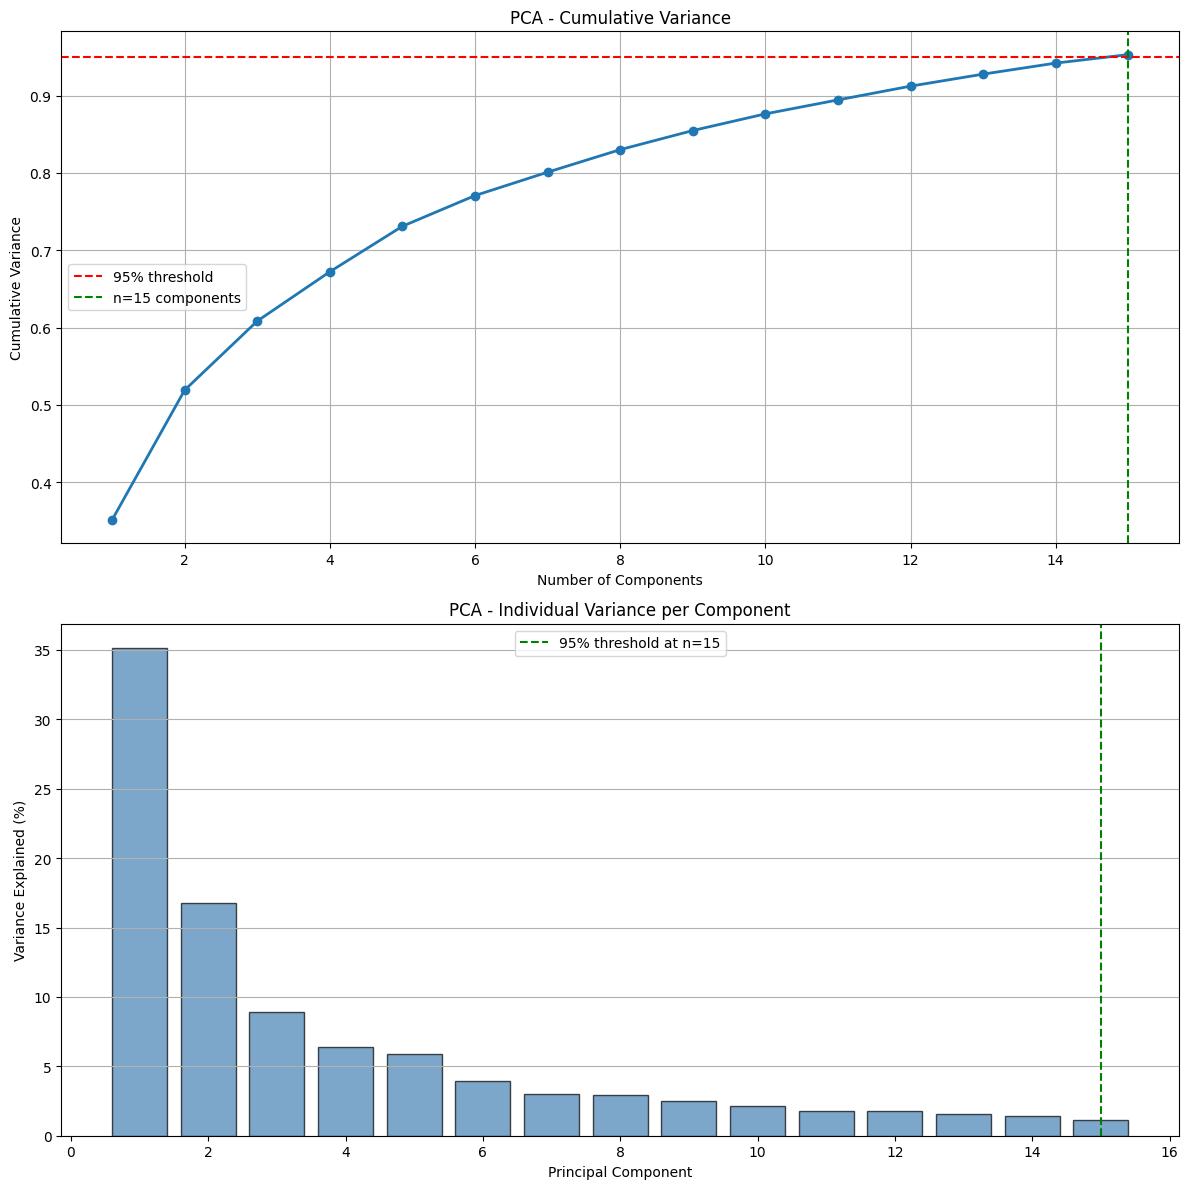

✅ Components needed for 95% variance: 15
✅ Variance explained by 15 components: 0.9531


In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax1.axvline(x=n_components_95, color='g', linestyle='--',
            label=f'n={n_components_95} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1),
        pca.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_95, color='g', linestyle='--',
            label=f'95% threshold at n={n_components_95}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 95% variance: {n_components_95}")
print(f"✅ Variance explained by {n_components_95} components: {cumvar[n_components_95-1]:.4f}")

In [ ]:
# Convert X_train_pca and X_test_pca to DataFrames first
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])

# Reset index on month DataFrames to align with PCA DataFrames
X_train_raw_month = X_train_raw_month.reset_index(drop=True)
X_test_raw_month = X_test_raw_month.reset_index(drop=True)

# Now concat safely
X_train_pca = pd.concat([X_train_pca_df, X_train_raw_month], axis=1)
X_test_pca = pd.concat([X_test_pca_df, X_test_raw_month], axis=1)

# Reset index on month DataFrames to align with PCA DataFrames
X_train_raw_5features = X_train_raw_5features.reset_index(drop=True)
X_test_raw_5features = X_test_raw_features.reset_index(drop=True)

# Now concat safely
X_train_pca = pd.concat([X_train_pca_df, X_train_raw_5features], axis=1)
X_test_pca = pd.concat([X_test_pca_df, X_test_raw_5features], axis=1)

In [ ]:
X_train_pca.columns

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
       'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'Month_1', 'Month_2', 'Month_3',
       'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9',
       'Month_10', 'Month_11', 'Month_12'],
      dtype='object')

# lazyPredict

In [ ]:
!pip install lazypredict tqdm

In [ ]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

In [ ]:
reg = LazyRegressor(verbose=1, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train_pca, X_test_pca, y_train, y_test)

print(models)

  0%|          | 0/42 [00:00<?, ?it/s]

                               Adjusted R-Squared     R-Squared         RMSE  \
Model                                                                          
ExtraTreesRegressor                      0.310809      0.326037     7.618878   
LGBMRegressor                            0.303910      0.319290     7.656917   
HistGradientBoostingRegressor            0.274980      0.290999     7.814414   
RandomForestRegressor                    0.265572      0.281799     7.864952   
MLPRegressor                             0.238840      0.255658     8.006803   
KNeighborsRegressor                      0.225350      0.242466     8.077448   
GradientBoostingRegressor                0.207153      0.224671     8.171766   
BaggingRegressor                         0.156969      0.175596     8.426418   
XGBRegressor                             0.151441      0.170190     8.454002   
PoissonRegressor                         0.119321      0.138780     8.612518   
ElasticNetCV                            

# OpTuna

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.2 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

In [ ]:
#prepare a version of X_train that already has month columns
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']

X_train_no_month = X_train_raw.copy()   # numeric only (month already dropped earlier)
X_train_month    = X_train_raw_month.reset_index(drop=True)
# helper: run CV with month columns reattached after PCA inside each fold
def cv_with_month(pipeline, X_num, X_mon, y, cv=4):
    from sklearn.model_selection import KFold

    # Reset all indices upfront so iloc slicing stays aligned
    X_num = X_num.reset_index(drop=True)
    X_mon = X_mon.reset_index(drop=True)
    y     = y.reset_index(drop=True)

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X_num):
        X_num_tr, X_num_val = X_num.iloc[train_idx], X_num.iloc[val_idx]
        X_mon_tr  = X_mon.iloc[train_idx].reset_index(drop=True)
        X_mon_val = X_mon.iloc[val_idx].reset_index(drop=True)
        y_tr  = y.iloc[train_idx].reset_index(drop=True)  # ← fixed
        y_val = y.iloc[val_idx].reset_index(drop=True)    # ← fixed

        steps_no_model = Pipeline(pipeline.steps[:-1])
        X_tr_pca  = steps_no_model.fit_transform(X_num_tr)
        X_val_pca = steps_no_model.transform(X_num_val)

        n_pcs   = X_tr_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_tr_final  = pd.concat([pd.DataFrame(X_tr_pca,  columns=pc_cols), X_mon_tr],  axis=1)
        X_val_final = pd.concat([pd.DataFrame(X_val_pca, columns=pc_cols), X_mon_val], axis=1)

        model = pipeline.steps[-1][1]
        model.fit(X_tr_final, y_tr)
        scores.append(model.score(X_val_final, y_val))
    return np.mean(scores)

In [ ]:
def et_objective(trial):
    model = ExtraTreesRegressor(
        n_estimators     = trial.suggest_int  ("n_estimators",  50, 400),
        max_depth        = trial.suggest_int  ("max_depth",      5,  40),
        min_samples_leaf = trial.suggest_int  ("min_samples_leaf",1,  5),
        max_features     = trial.suggest_categorical("max_features", ["sqrt","log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.75)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

et_study = optuna.create_study(direction="maximize")
et_study.optimize(et_objective, n_trials=50)
print("========== ET BEST ==========")
print(et_study.best_params)
print(f"Best R²: {et_study.best_value:.4f}")

[I 2026-05-06 00:38:36,261] A new study created in memory with name: no-name-1c88266d-a1a3-43bf-a61b-e52ac20a94fa
[I 2026-05-06 00:38:47,782] Trial 0 finished with value: 0.36677854154147205 and parameters: {'n_estimators': 228, 'max_depth': 40, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.36677854154147205.
[I 2026-05-06 00:38:55,574] Trial 1 finished with value: 0.1786387501467289 and parameters: {'n_estimators': 209, 'max_depth': 37, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.36677854154147205.
[I 2026-05-06 00:39:00,871] Trial 2 finished with value: 0.24059164418736226 and parameters: {'n_estimators': 139, 'max_depth': 24, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.36677854154147205.
[I 2026-05-06 00:39:12,415] Trial 3 finished with value: 0.2035569584906418 and parameters: {'n_estimators': 386, 'max_depth': 21, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with 

========== ET BEST ==========
{'n_estimators': 387, 'max_depth': 22, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best R²: 0.3705


In [ ]:
def lgbm_objective(trial):
    model = LGBMRegressor(
        n_estimators      = trial.suggest_int("n_estimators", 50, 400),
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.10),
        max_depth         = trial.suggest_int("max_depth", 3, 20),
        num_leaves        = trial.suggest_int("num_leaves", 15, 80),
        min_child_samples = trial.suggest_int("min_child_samples", 5, 50),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda        = trial.suggest_float("reg_lambda", 0.0, 2.0),
        n_jobs=-1,
        random_state=42,
        verbose=-1
    )

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.75)),
        ('model',   model)
    ])

    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)


lgbm_study = optuna.create_study(direction="maximize")
lgbm_study.optimize(lgbm_objective, n_trials=50)

print("========== LGBM BEST ==========")
print(lgbm_study.best_params)
print(f"Best R²: {lgbm_study.best_value:.4f}")

[I 2026-05-06 00:44:02,317] A new study created in memory with name: no-name-4aaf2fe4-c7fd-43fa-9a1c-c34eecc44672
[I 2026-05-06 00:44:24,524] Trial 0 finished with value: 0.32898152193200214 and parameters: {'n_estimators': 268, 'learning_rate': 0.08147297386412783, 'max_depth': 19, 'num_leaves': 60, 'min_child_samples': 25, 'subsample': 0.9929153921246809, 'colsample_bytree': 0.8941527462661442, 'reg_lambda': 0.2611002533902853}. Best is trial 0 with value: 0.32898152193200214.
[I 2026-05-06 00:44:41,315] Trial 1 finished with value: 0.34410639746002003 and parameters: {'n_estimators': 255, 'learning_rate': 0.03884302467863, 'max_depth': 13, 'num_leaves': 56, 'min_child_samples': 7, 'subsample': 0.9677427589057034, 'colsample_bytree': 0.818829283864133, 'reg_lambda': 1.7400069757915835}. Best is trial 1 with value: 0.34410639746002003.
[I 2026-05-06 00:44:43,760] Trial 2 finished with value: 0.30873695884675223 and parameters: {'n_estimators': 361, 'learning_rate': 0.06958387230960018

========== LGBM BEST ==========
{'n_estimators': 205, 'learning_rate': 0.054775150586439364, 'max_depth': 15, 'num_leaves': 36, 'min_child_samples': 5, 'subsample': 0.9821583116895447, 'colsample_bytree': 0.8725219351952457, 'reg_lambda': 1.5885243279899581}
Best R²: 0.3528


In [ ]:
def hgb_objective(trial):
    model = HistGradientBoostingRegressor(
        max_iter          = trial.suggest_int("max_iter", 50, 400),
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.10),
        max_depth         = trial.suggest_int("max_depth", 3, 20),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 5, 50),
        l2_regularization = trial.suggest_float("l2_regularization", 0.0, 2.0),
        random_state=42
    )

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=0.75)),
        ('model',   model)
    ])

    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)


hgb_study = optuna.create_study(direction="maximize")
hgb_study.optimize(hgb_objective, n_trials=50)

print("========== HGB BEST ==========")
print(hgb_study.best_params)
print(f"Best R²: {hgb_study.best_value:.4f}")

[I 2026-05-06 00:47:37,303] A new study created in memory with name: no-name-d8da33a3-76bf-47f4-bab4-d96cb5a9fda0
[I 2026-05-06 00:47:43,414] Trial 0 finished with value: 0.2838058849249958 and parameters: {'max_iter': 335, 'learning_rate': 0.025480447602870753, 'max_depth': 15, 'min_samples_leaf': 41, 'l2_regularization': 0.19765262343486145}. Best is trial 0 with value: 0.2838058849249958.
[I 2026-05-06 00:47:58,348] Trial 1 finished with value: 0.32537639131622453 and parameters: {'max_iter': 371, 'learning_rate': 0.04242964701488785, 'max_depth': 9, 'min_samples_leaf': 12, 'l2_regularization': 1.3554419748833728}. Best is trial 1 with value: 0.32537639131622453.
[I 2026-05-06 00:48:08,716] Trial 2 finished with value: 0.32669372517091566 and parameters: {'max_iter': 194, 'learning_rate': 0.03488973565367832, 'max_depth': 20, 'min_samples_leaf': 5, 'l2_regularization': 1.1948915218945653}. Best is trial 2 with value: 0.32669372517091566.
[I 2026-05-06 00:48:16,306] Trial 3 finished 

========== HGB BEST ==========
{'max_iter': 360, 'learning_rate': 0.05910294783583109, 'max_depth': 11, 'min_samples_leaf': 7, 'l2_regularization': 0.7505761480082558}
Best R²: 0.3474


# Start

In [ ]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=360,
    max_depth=11,
    learning_rate=0.059,
    min_samples_leaf=7,
    l2_regularization=0.75,
    random_state=42
)
# {'max_iter': 360, 'learning_rate': 0.05910294783583109, 'max_depth': 11, 'min_samples_leaf': 7, 'l2_regularization': 0.7505761480082558}
# Best R²: 0.3474
et_model = ExtraTreesRegressor(
    n_estimators=387,
    max_depth=22,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
# {'n_estimators': 387, 'max_depth': 22, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
# Best R²: 0.3705

lgbm_model = LGBMRegressor(
    n_estimators      = 205,
    learning_rate     = 0.055,
    max_depth         = 15,
    num_leaves        = 36,
    min_child_samples = 5,
    subsample         = 0.98,
    colsample_bytree  = 0.87,
    reg_lambda        = 1.59,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)
# {'n_estimators': 205, 'learning_rate': 0.054775150586439364, 'max_depth': 15, 'num_leaves': 36, 'min_child_samples': 5, 'subsample': 0.9821583116895447, 'colsample_bytree': 0.8725219351952457, 'reg_lambda': 1.5885243279899581}
# Best R²: 0.3528

xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    learning_rate=0.0243,
    max_depth=12,
    subsample=0.694,
    colsample_bytree=0.714,
    n_jobs=-1,
    random_state=42
)
#{'n_estimators': 400, 'learning_rate': 0.024294864577658625, 'max_depth': 12, 'subsample': 0.6937835791180113, 'colsample_bytree': 0.7141452636449821}

rf_model = RandomForestRegressor(
    n_estimators=422,
    max_depth=23,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features=0.458,
    n_jobs=-1,
    random_state=42
)
#{'n_estimators': 422, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.4576285822812347}

In [ ]:
from sklearn.base import clone
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

single_split_models = {
    'ExtraTrees': et_model,
    'LightGBM': lgbm_model,
    'HistGradientBoosting': hgb_model,
    'Voting (ET+LGBM+HGB)': VotingRegressor([
        ('et',  et_model),
        ('lgbm', lgbm_model),
        ('hgb', hgb_model)
    ])
}

print("=" * 80)
print("Single Split Results")
print("=" * 80)
print(f"{'Model':<28}{'R²':>14}{'RMSE':>14}{'MAE':>14}")
print("-" * 80)

single_split_results = []

for name, base_model in single_split_models.items():

    model = clone(base_model)

    model.fit(X_train_pca, y_train)
    preds = model.predict(X_test_pca)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    single_split_results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    print(
        f"{name:<28}"
        f"{r2:>14.4f}"
        f"{rmse:>14.4f}"
        f"{mae:>14.4f}"
    )

print("=" * 80)

single_split_results_df = pd.DataFrame(single_split_results)
single_split_results_df = single_split_results_df.sort_values(by="R2", ascending=False)

single_split_results_df

Single Split Results
Model                                   R²          RMSE           MAE
--------------------------------------------------------------------------------
ExtraTrees                          0.3566        7.4311        3.2670
LightGBM                            0.3093        7.6995        3.4198
HistGradientBoosting                0.3231        7.6221        3.4661
Voting (ET+LGBM+HGB)                0.3632        7.3933        3.2844


,Model,R2,RMSE,MAE
3,Voting (ET+LGBM+HGB),0.363169,7.393254,3.284396
0,ExtraTrees,0.356629,7.431123,3.266995
2,HistGradientBoosting,0.323136,7.622096,3.466130
1,LightGBM,0.309324,7.699472,3.419836


# K-Fold

In [ ]:
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

n_splits = 4
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Separate month columns before the loop
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']

X_month = X[month_cols].copy()
X_no_month = X.drop(columns=month_cols)

cv_models = {
    'ExtraTrees': et_model,
    'LightGBM': lgbm_model,
    'HistGradientBoosting': hgb_model,
    'Voting (ET+LGBM+HGB)': VotingRegressor([
        ('et', et_model),
        ('lgbm', lgbm_model),
        ('hgb', hgb_model)
    ])
}

print("=" * 80)
print("K-Fold Cross Validation Summary (k=4)")
print("=" * 80)
print(f"{'Model':<28}{'Mean R²':>14}{'Mean RMSE':>14}{'Mean MAE':>14}")
print("-" * 80)

for name, base_model in cv_models.items():

    r2_scores   = []
    rmse_scores = []
    mae_scores  = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):

        # Split numeric and month separately
        X_fold_train = X_no_month.iloc[train_idx]
        X_fold_test  = X_no_month.iloc[test_idx]

        month_fold_train = X_month.iloc[train_idx].reset_index(drop=True)
        month_fold_test  = X_month.iloc[test_idx].reset_index(drop=True)

        y_fold_train = Y.iloc[train_idx].reset_index(drop=True)
        y_fold_test  = Y.iloc[test_idx].reset_index(drop=True)

        # Impute → Scale → PCA (numeric only)
        imputer = SimpleImputer(strategy='median')
        X_train_imp = imputer.fit_transform(X_fold_train)
        X_test_imp  = imputer.transform(X_fold_test)

        scaler = StandardScaler()
        X_train_ss = scaler.fit_transform(X_train_imp)
        X_test_ss  = scaler.transform(X_test_imp)

        pca = PCA(n_components=0.95)
        X_train_pca = pca.fit_transform(X_train_ss)
        X_test_pca  = pca.transform(X_test_ss)

        # Convert PCA output to DataFrame and attach month columns
        n_pcs = X_train_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_train_final = pd.concat([
            pd.DataFrame(X_train_pca, columns=pc_cols),
            month_fold_train
        ], axis=1)

        X_test_final = pd.concat([
            pd.DataFrame(X_test_pca, columns=pc_cols),
            month_fold_test
        ], axis=1)

        # Train & evaluate
        model = clone(base_model)

        model.fit(X_train_final, y_fold_train)
        preds = model.predict(X_test_final)

        r2_scores.append(r2_score(y_fold_test, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_fold_test, preds)))
        mae_scores.append(mean_absolute_error(y_fold_test, preds))

    print(
        f"{name:<28}"
        f"{np.mean(r2_scores):>14.4f}"
        f"{np.mean(rmse_scores):>14.4f}"
        f"{np.mean(mae_scores):>14.4f}"
    )

print("=" * 80)

K-Fold Cross Validation Summary (k=4)
Model                              Mean R²     Mean RMSE      Mean MAE
--------------------------------------------------------------------------------
ExtraTrees                          0.3762        7.5933        3.2596
LightGBM                            0.3478        7.7609        3.3135
HistGradientBoosting                0.3397        7.8123        3.3947
Voting (ET+LGBM+HGB)                0.3786        7.5790        3.2185
